# **Live Coding 2**

En esta demo trabajaremos con un dataset simulado de gran tamaño para recorrer dos enfoques distintos de Machine Learning en Spark MLlib.
Primero prepararemos los datos transformando variables categóricas y numéricas, ya que los algoritmos de MLlib requieren una representación vectorial de las características.
Después entrenaremos un modelo supervisado de clasificación utilizando regresión logística y evaluaremos su desempeño con AUC.
Finalmente, aplicaremos un modelo no supervisado con K-Means para identificar posibles segmentos dentro de los datos, evaluando la calidad de los clústeres con Silhouette Score.

1. Preparar datos y convertir variables

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import rand, when, floor, col

spark = SparkSession.builder.appName("Demo_MLlib").getOrCreate()

n = 1000000

df = spark.range(0, n) \
    .withColumn("edad", (rand()*42 + 18).cast("int")) \
    .withColumn("ingresos", (rand()*2500000 + 300000).cast("double")) \
    .withColumn("antiguedad", (rand()*15).cast("int")) \
    .withColumn(
        "canal",
        when(rand() < 0.33, "web")
        .when(rand() < 0.66, "tienda")
        .otherwise("app")
    ) \
    .withColumn(
        "compra",
        when((col("ingresos") > 1200000) & (col("edad") < 45), 1).otherwise(0)
    )

df.show(5)

+---+----+------------------+----------+------+------+
| id|edad|          ingresos|antiguedad| canal|compra|
+---+----+------------------+----------+------+------+
|  0|  30|1494537.5162448157|        14|tienda|     1|
|  1|  21|2387754.5591857615|        14|tienda|     1|
|  2|  32|1155261.9548845869|         4|   web|     0|
|  3|  57|1576818.5112620175|         4|tienda|     0|
|  4|  52|1215853.4256664463|         1|tienda|     0|
+---+----+------------------+----------+------+------+
only showing top 5 rows


In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

indexer = StringIndexer(inputCol="canal", outputCol="canal_index")
encoder = OneHotEncoder(inputCols=["canal_index"], outputCols=["canal_ohe"])

df_indexed = indexer.fit(df).transform(df)
df_encoded = encoder.fit(df_indexed).transform(df_indexed)

assembler = VectorAssembler(
    inputCols=["edad", "ingresos", "antiguedad", "canal_ohe"],
    outputCol="features"
)

df_final = assembler.transform(df_encoded).select("features", "compra")
df_final.show(5, truncate=False)

+--------------------------------------+------+
|features                              |compra|
+--------------------------------------+------+
|[30.0,1494537.5162448157,14.0,1.0,0.0]|1     |
|[21.0,2387754.5591857615,14.0,1.0,0.0]|1     |
|[32.0,1155261.9548845869,4.0,0.0,1.0] |0     |
|[57.0,1576818.5112620175,4.0,1.0,0.0] |0     |
|[52.0,1215853.4256664463,1.0,1.0,0.0] |0     |
+--------------------------------------+------+
only showing top 5 rows


2. Entrenar un modelo supervisado

In [ ]:
from pyspark.ml.classification import LogisticRegression

train_df, test_df = df_final.randomSplit([0.8, 0.2], seed=42)

lr = LogisticRegression(labelCol="compra", featuresCol="features")
lr_model = lr.fit(train_df)

predictions = lr_model.transform(test_df)
predictions.select("compra", "prediction", "probability").show(5, truncate=False)

+------+----------+----------------------------------------+
|compra|prediction|probability                             |
+------+----------+----------------------------------------+
|0     |0.0       |[0.7137551511018652,0.28624484889813484]|
|0     |0.0       |[0.6979239709712767,0.3020760290287233] |
|0     |0.0       |[0.6812784716875216,0.31872152831247835]|
|0     |0.0       |[0.6121852851890796,0.38781471481092045]|
|0     |0.0       |[0.5295129841082898,0.47048701589171016]|
+------+----------+----------------------------------------+
only showing top 5 rows


3. Evaluar el modelo

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator_auc = BinaryClassificationEvaluator(
    labelCol="compra",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

auc = evaluator_auc.evaluate(predictions)
print("AUC del modelo:", auc)

AUC del modelo: 0.9439974339202775


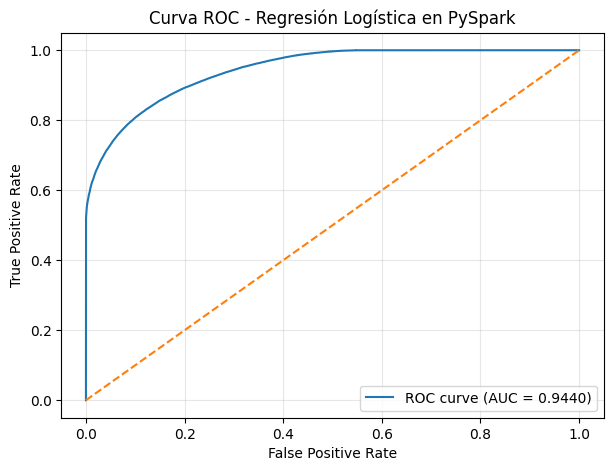

In [ ]:
from pyspark.ml.functions import vector_to_array
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as sk_auc

roc_df = predictions.select(
    col("compra"),
    vector_to_array("probability")[1].alias("prob_1")
)

roc_pd = roc_df.toPandas()

fpr, tpr, thresholds = roc_curve(roc_pd["compra"], roc_pd["prob_1"])
roc_auc = sk_auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística en PySpark")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="compra",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator_acc.evaluate(predictions)
print("Accuracy del modelo:", accuracy)

Accuracy del modelo: 0.8605809584715616


4. Implementar modelo no supervisado con K-Means

In [ ]:
df_kmeans = assembler.transform(df_encoded).select("features")

from pyspark.ml.clustering import KMeans

kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=3, seed=42)
kmeans_model = kmeans.fit(df_kmeans)

kmeans_predictions = kmeans_model.transform(df_kmeans)
kmeans_predictions.select("features", "cluster").show(5, truncate=False)

+--------------------------------------+-------+
|features                              |cluster|
+--------------------------------------+-------+
|[30.0,1494537.5162448157,14.0,1.0,0.0]|2      |
|[21.0,2387754.5591857615,14.0,1.0,0.0]|0      |
|[32.0,1155261.9548845869,4.0,0.0,1.0] |2      |
|[57.0,1576818.5112620175,4.0,1.0,0.0] |2      |
|[52.0,1215853.4256664463,1.0,1.0,0.0] |2      |
+--------------------------------------+-------+
only showing top 5 rows


In [ ]:
from pyspark.ml.evaluation import ClusteringEvaluator

clustering_evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster",
    metricName="silhouette"
)

silhouette = clustering_evaluator.evaluate(kmeans_predictions)
print("Silhouette Score:", silhouette)

Silhouette Score: 0.7531641650891542
